In [3]:
import pandas as pd
import collections
import plotnine as p9
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
datadir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/kallisto_output/merged/")
indexdir = Path("/gpfs/commons/groups/knowles_lab/index/kallisto/mus_musculus/")

count_file = datadir / "correct100.txt.gz"

In [40]:
with open(datadir / "matrix.ec","r") as f: 
    kallisto_ecs = [ [int(g) for g in s.split("\t")[1].strip().split(",")] for s in f.readlines() ]

## Distribution of EC sizes

2700

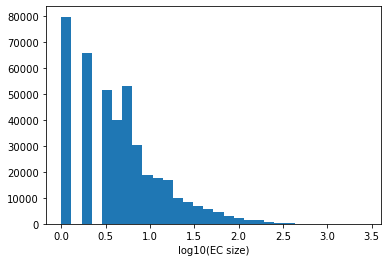

In [80]:
kallisto_EC_sizes = np.array([ len(g) for g in kallisto_ecs ]) 
plt.hist(np.log10(EC_sizes),30)
plt.xlabel("log10(EC size)")
max(kallisto_EC_sizes)

So most ECs are <=10. There is a small tail of ECs bigger than 100. The biggest is 2700! 

In [1]:
with open("my.ec","r") as f: 
    ecs = [ [int(g) for g in s.strip().split(",")] for s in f.readlines()[1:] ]

2700

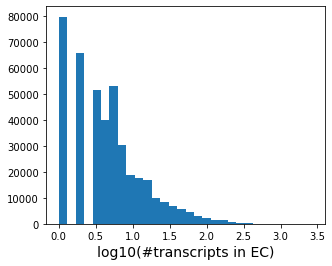

In [9]:
EC_sizes = np.array([ len(g) for g in ecs ])
plt.figure(figsize=[5,4])
plt.hist(np.log10(EC_sizes),30)
plt.xlabel("log10(#transcripts in EC)", fontsize=14)
plt.savefig("EC sizes.pdf")
max(EC_sizes)

Basically the same as the kallisto ECs. 

## What is going on with the massive EC? 

Is this many transcripts from the same gene? To some extent: 

In [35]:
massive_ec = ecs[418893]
pd.Series([ t2g_dic[g] for g in massive_ec]).value_counts()

ENSMUSG00000040687.16    18
ENSMUSG00000068234.7     12
ENSMUSG00000024921.17    12
ENSMUSG00000062818.7     12
ENSMUSG00000064302.13    10
                         ..
ENSMUSG00000082980.5      1
ENSMUSG00000050919.9      1
ENSMUSG00000022863.15     1
ENSMUSG00000042379.8      1
ENSMUSG00000039131.15     1
Length: 1886, dtype: int64

In [42]:
nnz = sum(EC_sizes)

## Connected components
from scipy.sparse.csgraph import connected_components
import torch
import scipy.sparse as sp

Represent ECs as EC x transcripts sparse matrix. 

In [ ]:
from scipy.sparse.csgraph import connected_components
import torch
import scipy.sparse as sp


In [43]:
indices = np.zeros((2,nnz), dtype=int) # cell then EC idx
nz_idx = 0
for ec_idx,ec in enumerate(ecs): 
    nhere = len(ec)
    indices[0,nz_idx:nz_idx+nhere] = ec_idx
    indices[1,nz_idx:nz_idx+nhere] = ec
    nz_idx += nhere

Getting transcripts x transcripts adjacency matrix

In [89]:
# ec_transcript_mat = torch.sparse_coo_tensor(indices, np.ones(nnz))
ec_transcript_mat = sp.coo_matrix((np.ones(nnz), indices))
trans_adj = ec_transcript_mat.transpose() @ ec_transcript_mat

In [90]:
n_components, labels = connected_components(csgraph=scipy_sparse, directed=False, return_labels=True)
n_components # 19163!

19163

In [91]:
pd.Series(labels).value_counts()

146      67507
2696       214
2140        71
6467        57
654         56
         ...  
8717         1
8720         1
8721         1
8724         1
19162        1
Length: 19163, dtype: int64

So one pretty massive connected component (67k!) I wonder how close it is to being disconnected. 

(array([1.2189e+04, 1.6850e+03, 1.1270e+03, 9.5000e+02, 1.3170e+03,
        9.8700e+02, 5.3000e+02, 2.4800e+02, 9.9000e+01, 2.3000e+01,
        5.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([0.        , 0.16097829, 0.32195659, 0.48293488, 0.64391317,
        0.80489147, 0.96586976, 1.12684806, 1.28782635, 1.44880464,
        1.60978294, 1.77076123, 1.93173952, 2.09271782, 2.25369611,
        2.4146744 , 2.5756527 , 2.73663099, 2.89760929, 3.05858758,
        3.21956587, 3.38054417, 3.54152246, 3.70250075, 3.86347905,
        4.02445734, 4.18543563, 4.34641393, 4.50739222, 4.66837051,
        4.82934881]),
 <BarContainer object of 30 artists>)

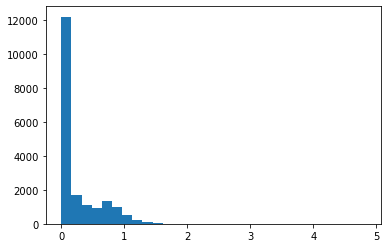

In [74]:
plt.hist(np.log10(pd.Series(labels).value_counts()),30)

In [105]:
big_comp = sp.csr_matrix(ec_transcript_mat)[:,labels==146]

In [120]:
row_sums = np.squeeze(np.asarray(big_comp.sum(1)))

In [122]:
big_comp = big_comp[row_sums>0,:]

In [125]:
row_sums = np.squeeze(np.asarray(big_comp.sum(1)))
col_sums = np.squeeze(np.asarray(big_comp.sum(0)))

In [145]:
scaled_H = sp.diags(1.0/np.sqrt(row_sums)) @ big_comp @ sp.diags(1.0/np.sqrt(col_sums)) 

In [146]:
from scipy.sparse.linalg import svds
u, s, v = svds(scaled_H, k=4) # takes a while! 

In [147]:
u.shape

(328392, 4)

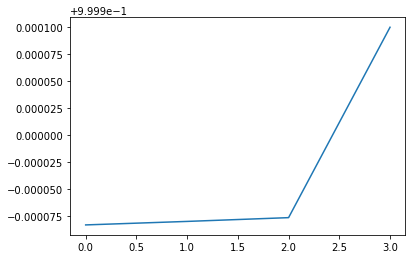

In [152]:
plt.plot(s)

In [162]:
alloc = v[-2,:]

In [163]:
sum(alloc>0)

67437

In [164]:
sum(alloc<=0)

70

In [165]:
type(big_comp)

scipy.sparse.csr.csr_matrix

In [167]:
big_comp.indices.shape

(3799182,)

In [172]:
np.prod(big_comp.shape)

22168758744

In [173]:
3799182 / 22168758744

0.00017137549485165708

In [175]:
P = np.array([[4, 0, 1, 0],
              [0, 5, 0, 0],
              [1, 0, 3, 2],
              [0, 0, 2, 4]])
A = sp.csc_matrix(P)
b = np.eye(4)
x, exit_code = sp.linalg.cg(A, b)

ValueError: A and b have incompatible dimensions

In [176]:
b.shape

(4, 4)